=== Loading Dataset ===
Original shape: (30, 7)
   Customer_ID  Age Monthly_Spend  Items_Purchased  Website_Visits  \
0          101   25          1200                2             5.0   
1          102   32          2500                4            12.0   
2          103   28          1800                3             8.0   
3          104   45          4200                6            20.0   
4          105   23           900                1             3.0   

   Premium_Member  Annual_Spend  
0             0.0        4500.0  
1             1.0        8200.0  
2             0.0        6200.0  
3             1.0       12500.0  
4             0.0        3200.0  
Cleaned shape: (28, 7)

=== 5-Fold Cross Validation ===
Fold 1: MSE = 51,189 | R² = 0.9909
Fold 2: MSE = 32,163 | R² = 0.9946
Fold 3: MSE = 51,976 | R² = 0.9951
Fold 4: MSE = 56,191 | R² = 0.9955
Fold 5: MSE = 35,629 | R² = 0.9972

=== Cross Validation Results ===
Mean MSE: 45,430 (± 9,632)
Mean R² : 0.9947


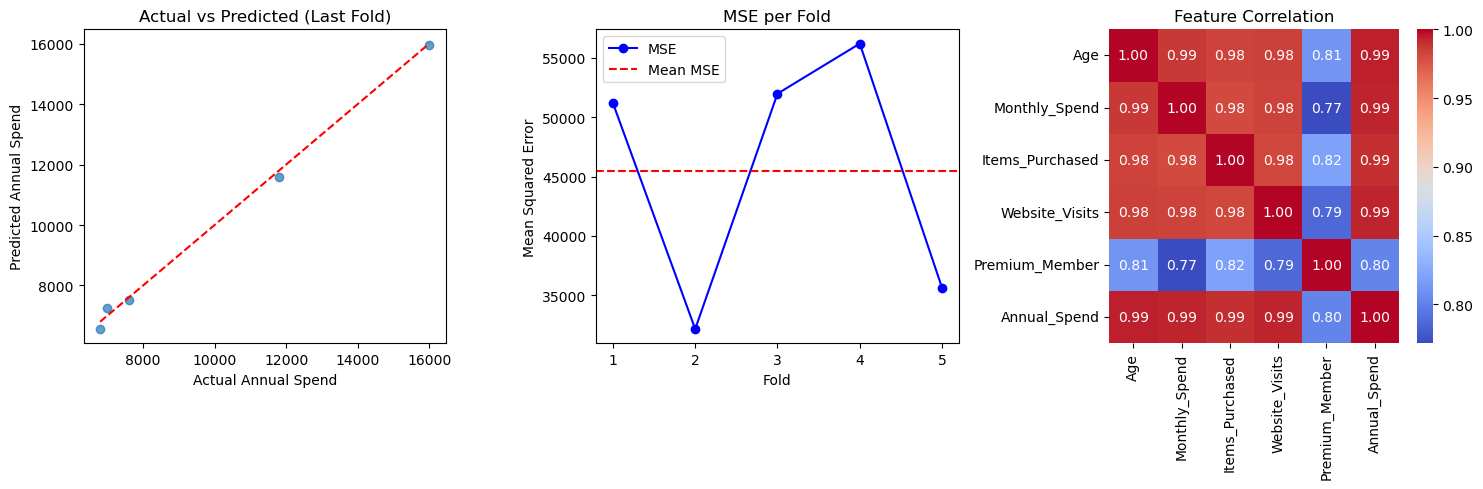


=== Full Model Coefficients ===
Age                :   110.55
Monthly_Spend      :     0.83
Items_Purchased    :   255.32
Website_Visits     :   154.75
Premium_Member     :    99.35


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# ====================== 1. IMPORTING & LOADING DATA ======================
print("=== Loading Dataset ===")
df = pd.read_csv(r"C:\Users\Acer\Desktop\ML projects\ecommerce_linear_regression_dataset (2).csv")

print(f"Original shape: {df.shape}")
print(df.head())

# ====================== 2. DATA CLEANING ======================
# Convert columns to numeric
numeric_cols = ['Age', 'Monthly_Spend', 'Items_Purchased', 
                'Website_Visits', 'Premium_Member', 'Annual_Spend']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with missing target
df = df.dropna(subset=['Annual_Spend'])

# Fill other missing values with median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Remove extreme outlier
df = df[df['Monthly_Spend'] < 10000]

print(f"Cleaned shape: {df.shape}")

# ====================== 3. FEATURES & TARGET ======================
X = df[['Age', 'Monthly_Spend', 'Items_Purchased', 
        'Website_Visits', 'Premium_Member']]
y = df['Annual_Spend']

# ====================== 4. K-FOLD CROSS VALIDATION ======================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()

mse_scores = []
r2_scores = []
fold = 1

print("\n=== 5-Fold Cross Validation ===")

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    mse_scores.append(mse)
    r2_scores.append(r2)
    
    print(f"Fold {fold}: MSE = {mse:,.0f} | R² = {r2:.4f}")
    fold += 1

print("\n=== Cross Validation Results ===")
print(f"Mean MSE: {np.mean(mse_scores):,.0f} (± {np.std(mse_scores):,.0f})")
print(f"Mean R² : {np.mean(r2_scores):.4f}")

# ====================== 5. VISUALIZATION WITH MATPLOTLIB ======================
plt.figure(figsize=(15, 5))

# Plot 1: Actual vs Predicted (last fold)
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Annual Spend')
plt.ylabel('Predicted Annual Spend')
plt.title('Actual vs Predicted (Last Fold)')

# Plot 2: MSE across folds
plt.subplot(1, 3, 2)
plt.plot(range(1, 6), mse_scores, 'bo-', label='MSE')
plt.axhline(np.mean(mse_scores), color='red', linestyle='--', label='Mean MSE')
plt.xlabel('Fold')
plt.ylabel('Mean Squared Error')
plt.title('MSE per Fold')
plt.legend()

# Plot 3: Correlation Heatmap
plt.subplot(1, 3, 3)
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation')

plt.tight_layout()
plt.show()

# ====================== 6. FULL MODEL SUMMARY ======================
model.fit(X, y)
print("\n=== Full Model Coefficients ===")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature:18} : {coef:8.2f}")